In [ ]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
os.path.getsize("nhtsa_vehicle_safety_recall_intelligence_ultimate.csv")


74820119

In [8]:
df = pd.read_csv('nhtsa_vehicle_safety_recall_intelligence_ultimate.csv')
df

,record_id,nhtsa_record_id,recall_campaign_id,manufacturer_campaign_id,vehicle_make,vehicle_model,vehicle_year,vehicle_year_num,vehicle_era,manufacturer_name,...,source_url,scrape_date,dataset_version,record_creation_date,RCL_CMPT_ID,MFR_COMP_NAME,MFR_COMP_DESC,MFR_COMP_PTNO,creation_date_parsed,defect_severity_score
0,835d8908b3a39d,105867,14V400000,14350,OLDSMOBILE,INTRIGUE,1998.0,1998.0,1990s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202679000000212,NaN,NaN,NaN,2014-07-07,0.3979
1,1e393b1efc0ea4,105872,14V400000,14350,CHEVROLET,MALIBU CLASSIC,2005.0,2005.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000204360000000212,NaN,NaN,NaN,2014-07-07,0.3979
2,1ea55f8d43bf01,105885,14V400000,14350,OLDSMOBILE,ALERO,2001.0,2001.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202733000000212,NaN,NaN,NaN,2014-07-07,0.3979
3,3588d2734c086b,105883,14V400000,14350,PONTIAC,GRAND AM,2000.0,2000.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202623000000212,NaN,NaN,NaN,2014-07-07,0.3979
4,ab8db036507579,105882,14V400000,14350,PONTIAC,GRAND AM,2002.0,2002.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202625000000212,NaN,NaN,NaN,2014-07-07,0.3979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47702,9435c79ecfa868,159592,20V195000,V2003,CHEVROLET,6500XD,2019.0,2019.0,2010s,"Isuzu Technical Center of America, Inc.",...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20200403,102456004127742000000207,Harness,Chassis frame harness leading from relay box t...,8983198205,2020-04-03,0.2884
47703,05a14affdb297b,159591,20V195000,V2003,CHEVROLET,6500XD,2018.0,2018.0,2010s,"Isuzu Technical Center of America, Inc.",...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20200403,102456004127741000000207,Harness,Chassis frame harness leading from relay box t...,8983198205,2020-04-03,0.2884
47704,ca834dfa7369e1,159590,20V195000,V2003,ISUZU,FTR,2019.0,2019.0,2010s,"Isuzu Technical Center of America, Inc.",...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20200403,102456003752720000000207,Harness,Chassis frame harness leading from relay box t...,8983198205,2020-04-03,0.2884
47705,c9af5f7a4b05e8,159589,20V195000,V2003,ISUZU,FTR,2018.0,2018.0,2010s,"Isuzu Technical Center of America, Inc.",...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20200403,102456003752719000000207,Harness,Chassis frame harness leading from relay box t...,8983198205,2020-04-03,0.2884


In [9]:
interesting_cols = ['component_category','vehicle_make','recall_type_label', 'units_affected_num', 'fire_risk_flag']

#Potential Predictors
print(df['defect_severity'].value_counts())

#Maybe look at if manufacturer is a predictor
df[interesting_cols]

defect_severity
MEDIUM      12908
LOW         12073
HIGH        12033
CRITICAL    10693
Name: count, dtype: int64


,component_category,vehicle_make,recall_type_label,units_affected_num,fire_risk_flag
0,Air Bag,OLDSMOBILE,Vehicle,5877718,0
1,Air Bag,CHEVROLET,Vehicle,5877718,0
2,Air Bag,OLDSMOBILE,Vehicle,5877718,0
3,Air Bag,PONTIAC,Vehicle,5877718,0
4,Air Bag,PONTIAC,Vehicle,5877718,0
...,...,...,...,...,...
47702,Steering,CHEVROLET,Vehicle,2399,0
47703,Steering,CHEVROLET,Vehicle,2399,0
47704,Steering,ISUZU,Vehicle,2399,0
47705,Steering,ISUZU,Vehicle,2399,0


In [10]:
df['defect_severity_score'].sort_values(ascending=False)

26287    0.5233
26288    0.5233
26345    0.5233
26327    0.5233
26286    0.5233
          ...  
18965    0.0872
18967    0.0872
10104    0.0538
5704     0.0538
10204    0.0538
Name: defect_severity_score, Length: 47707, dtype: float64

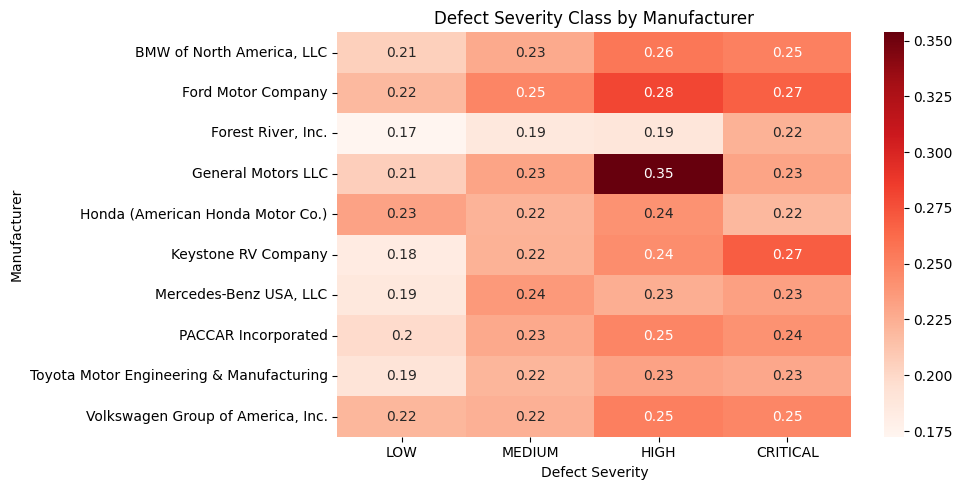

In [26]:
top = (df['manufacturer_name'].value_counts().head(10).index)
filtered = df[df['manufacturer_name'].isin(top)]
data = filtered.pivot_table(values='defect_severity_score', index='manufacturer_name', columns='defect_severity',aggfunc='mean')
severity_order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
data = data[severity_order]
plt.figure(figsize=(10, 5))

sns.heatmap(data, annot=True, cmap="Reds")

plt.title("Defect Severity Class by Manufacturer")
plt.xlabel("Defect Severity")
plt.ylabel("Manufacturer")
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('make_origin')['defect_severity_score'].mean()


make_origin
EV-First Brand    0.264449
European          0.239403
German            0.222416
Japanese          0.229951
Korean            0.231021
Other             0.240403
US Domestic       0.249014
Name: defect_severity_score, dtype: float64

In [29]:
df.columns

Index(['record_id', 'nhtsa_record_id', 'recall_campaign_id',
       'manufacturer_campaign_id', 'vehicle_make', 'vehicle_model',
       'vehicle_year', 'vehicle_year_num', 'vehicle_era', 'manufacturer_name',
       'manufacturer_text', 'make_origin', 'recall_type_code',
       'recall_type_label', 'component_name', 'component_category',
       'recall_initiation_date', 'recall_date_parsed', 'report_received_date',
       'owner_notification_date', 'notification_date_parsed',
       'manufacture_date_begin', 'manufacture_date_end', 'recall_year',
       'recall_month', 'recall_quarter', 'recall_age_days',
       'days_to_owner_notification', 'potential_units_affected',
       'units_affected_num', 'recall_scale', 'defect_summary',
       'consequence_summary', 'corrective_action', 'notes', 'defect_severity',
       'fire_risk_flag', 'manufacturer_recall_count', 'is_repeat_manufacturer',
       'recall_risk_score', 'risk_tier', 'influenced_by', 'data_source',
       'source_url', 'scrape

In [31]:
df.groupby('vehicle_model')['defect_severity_score'].mean()

vehicle_model
!ESCAPE 21                         0.371900
!MX-5                              0.217700
1 SERIES                           0.211882
1 SERIES M                         0.186650
1.5L ECOBOOST RFF CYLINDER HEAD    0.234300
                                     ...   
redundant RX PLUG-IN HYBRID        0.193100
redundant SEISMIC                  0.187060
redundant SIENNA                   0.227200
redundant TOYOTA SIENNA HYBRID     0.194800
redundant XC90MHEV                 0.218300
Name: defect_severity_score, Length: 5048, dtype: float64

In [34]:
df.groupby('component_category')['defect_severity_score'].mean()

component_category
Air Bag                0.241633
Brakes                 0.261222
Child Seat             0.246500
Electrical             0.231402
Engine / Powertrain    0.245486
Fire Risk              0.284637
Fuel System            0.233164
Other                  0.213442
Seat Belts             0.254284
Software / EV          0.218830
Steering               0.243183
Suspension             0.233134
Tires / Wheels         0.209067
Visibility             0.209661
Name: defect_severity_score, dtype: float64

In [36]:
df.groupby('vehicle_era')['defect_severity_score'].mean()

vehicle_era
1980s    0.221963
1990s    0.245861
2000s    0.241504
2010s    0.238209
2020s    0.240705
Name: defect_severity_score, dtype: float64

In [37]:
df.groupby('is_repeat_manufacturer')['defect_severity_score'].mean()

is_repeat_manufacturer
0    0.253316
1    0.239698
Name: defect_severity_score, dtype: float64

In [38]:
df.groupby('influenced_by')['defect_severity_score'].mean()

influenced_by
MFR     0.241849
ODI     0.230191
OVSC    0.250077
Name: defect_severity_score, dtype: float64